<a href="https://colab.research.google.com/github/Gnanadeep7/scalping_trades_analysis/blob/main/scalping_trades_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd

df = pd.read_csv('/content/xauusd.csv')

In [39]:
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,id,dateStart,dateEnd,pair,uPnL,rPnL,side,entryPrice,initalSL,maxTP,...,amountClosed,status,day,tags,avgClosePrice,avgRiskReward,maxRiskReward,exchangeRate,initialBalance,currentRealizedBalance
0,234020674,2026/05/04 06:35:00,2026/05/04 10:01:00,XAUUSD,0,477.54,sell,4589.706,4598.567,4571.561,...,112.85,closed,1,NaN,4585.47437,0.48,2.05,1,100000,100477.54
1,234022766,2026/05/05 07:14:00,2026/05/05 07:47:00,XAUUSD,0,-1000.03,buy,4553.885,4546.722,NaN,...,139.61,closed,2,NaN,4546.72197,-1.00,0.00,1,100000,99477.51
2,234025347,2026/05/07 05:35:00,2026/05/07 06:31:00,XAUUSD,0,1613.92,buy,4703.108,4694.193,4721.678,...,112.17,closed,4,NaN,4717.49616,1.61,2.08,1,100000,101091.43
3,234317978,2026/05/08 05:29:00,2026/05/08 06:00:00,XAUUSD,0,165.05,buy,4719.105,4709.054,4720.764,...,99.49,closed,5,NaN,4720.76396,0.17,0.17,1,100000,101256.48
4,234319307,2026/05/12 06:05:00,2026/05/12 08:02:00,XAUUSD,0,65.47,sell,4706.787,4717.081,4706.113,...,97.14,closed,2,NaN,4706.11302,0.07,0.07,1,100000,101321.95


In [40]:
df["dateStart"] = pd.to_datetime(df["dateStart"])
df["dateEnd"] = pd.to_datetime(df["dateEnd"])

print("DataFrame Info after date conversion:")
df.info()

print("\nMissing values per column:")
display(df.isnull().sum())

DataFrame Info after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      64 non-null     int64         
 1   dateStart               64 non-null     datetime64[ns]
 2   dateEnd                 64 non-null     datetime64[ns]
 3   pair                    64 non-null     object        
 4   uPnL                    64 non-null     int64         
 5   rPnL                    64 non-null     float64       
 6   side                    64 non-null     object        
 7   entryPrice              64 non-null     float64       
 8   initalSL                64 non-null     float64       
 9   maxTP                   31 non-null     float64       
 10  idealTP                 64 non-null     float64       
 11  amount                  64 non-null     float64       
 12  amountClosed  

,0
id,0
dateStart,0
dateEnd,0
pair,0
uPnL,0
rPnL,0
side,0
entryPrice,0
initalSL,0
maxTP,33


In [41]:
df = df.drop(columns=['tags'])

# Impute missing values in 'maxTP' with the median
median_maxTP = df['maxTP'].median()
df['maxTP'] = df['maxTP'].fillna(median_maxTP)

print("DataFrame Info after handling missing values:")
df.info()

print("\nMissing values per column after handling:")
display(df.isnull().sum())

DataFrame Info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      64 non-null     int64         
 1   dateStart               64 non-null     datetime64[ns]
 2   dateEnd                 64 non-null     datetime64[ns]
 3   pair                    64 non-null     object        
 4   uPnL                    64 non-null     int64         
 5   rPnL                    64 non-null     float64       
 6   side                    64 non-null     object        
 7   entryPrice              64 non-null     float64       
 8   initalSL                64 non-null     float64       
 9   maxTP                   64 non-null     float64       
 10  idealTP                 64 non-null     float64       
 11  amount                  64 non-null     float64       
 12  amount

,0
id,0
dateStart,0
dateEnd,0
pair,0
uPnL,0
rPnL,0
side,0
entryPrice,0
initalSL,0
maxTP,0


In [42]:
df['tradeDuration'] = (df['dateEnd'] - df['dateStart']).dt.total_seconds() / 60  # Duration in minutes

print("Descriptive statistics for trade duration (minutes):")
display(df['tradeDuration'].describe())

Descriptive statistics for trade duration (minutes):


,tradeDuration
count,64.000000
mean,115.312500
std,504.061626
min,1.000000
25%,11.750000
50%,21.500000
75%,75.000000
max,4044.000000


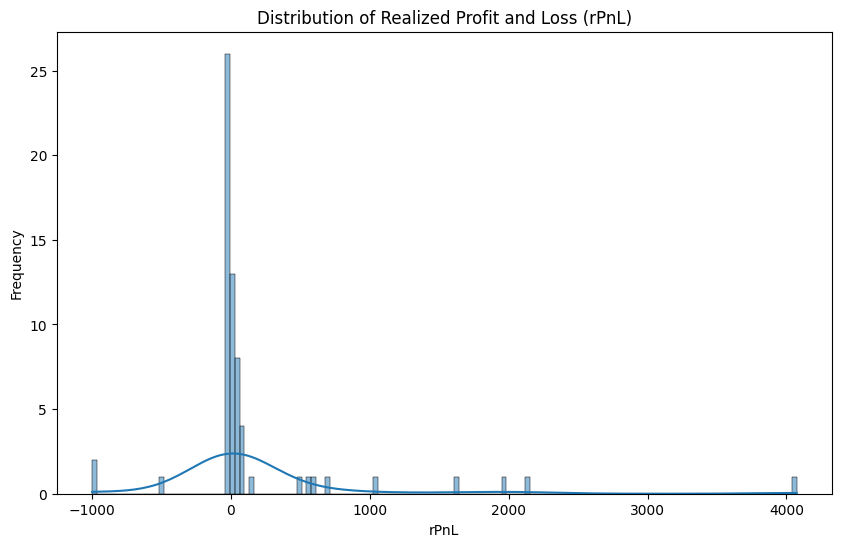

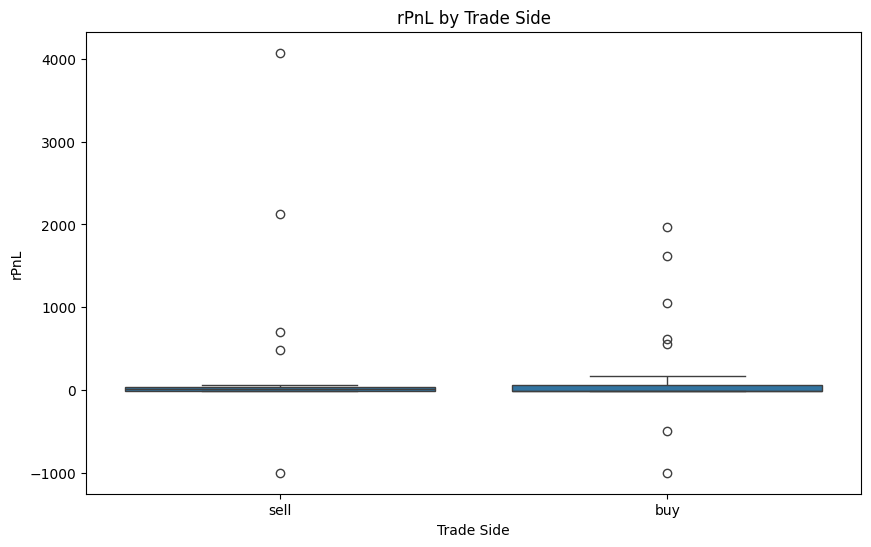

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['rPnL'], kde=True)
plt.title('Distribution of Realized Profit and Loss (rPnL)')
plt.xlabel('rPnL')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['side'], y=df['rPnL'])
plt.title('rPnL by Trade Side')
plt.xlabel('Trade Side')
plt.ylabel('rPnL')
plt.show()

### Distribution of Price-Related Features

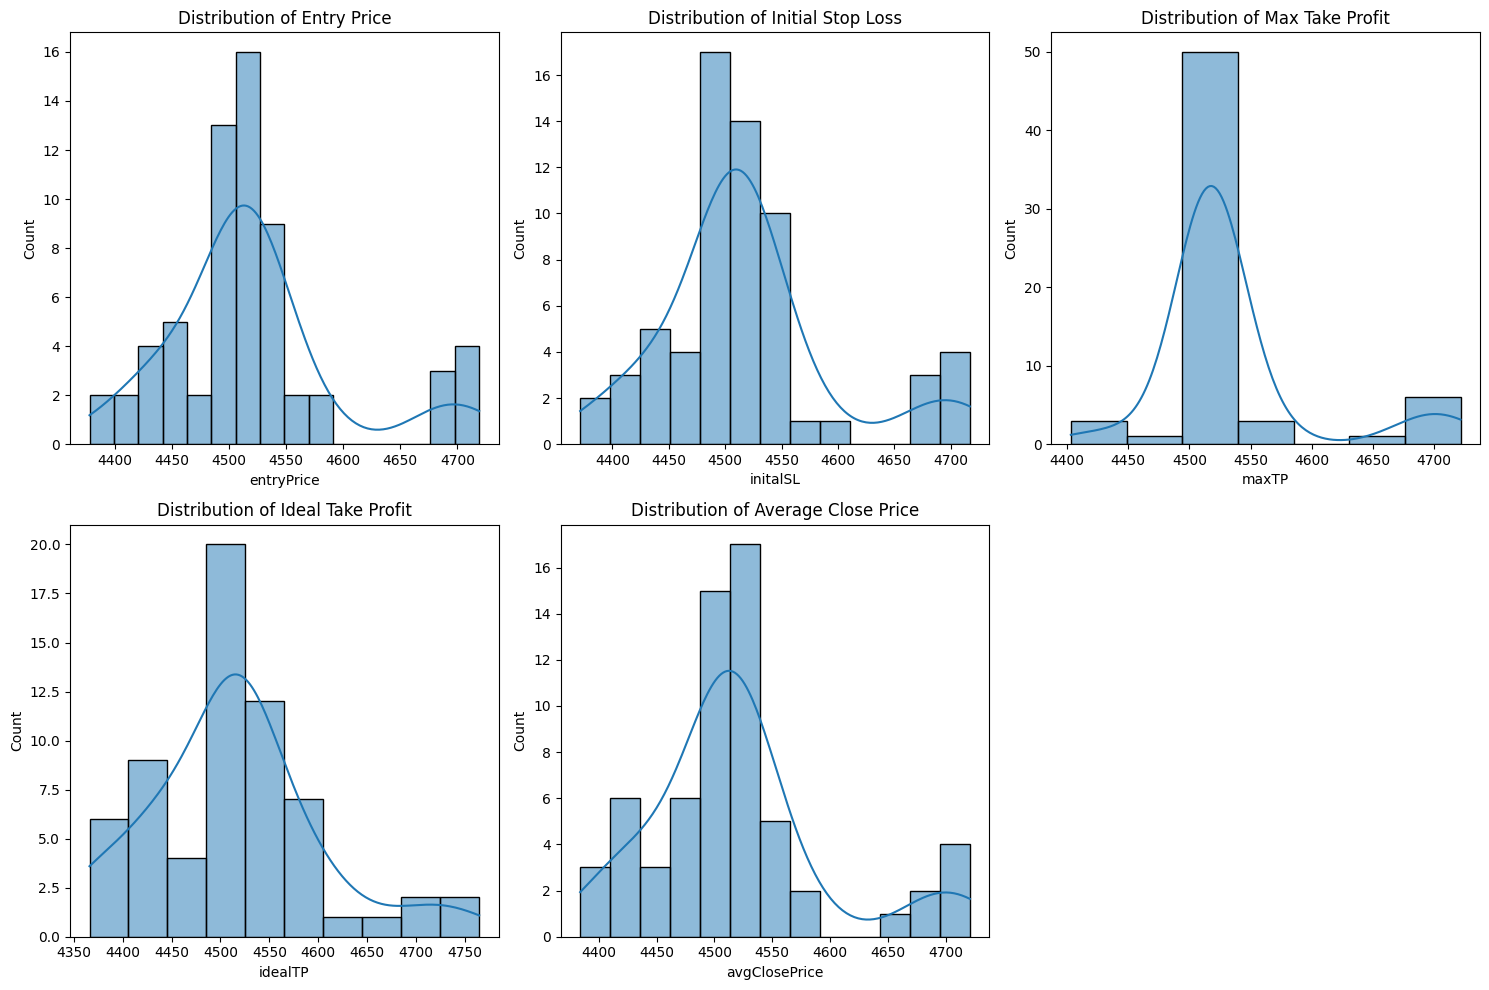

In [44]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['entryPrice'], kde=True)
plt.title('Distribution of Entry Price')

plt.subplot(2, 3, 2)
sns.histplot(df['initalSL'], kde=True)
plt.title('Distribution of Initial Stop Loss')

plt.subplot(2, 3, 3)
sns.histplot(df['maxTP'], kde=True)
plt.title('Distribution of Max Take Profit')

plt.subplot(2, 3, 4)
sns.histplot(df['idealTP'], kde=True)
plt.title('Distribution of Ideal Take Profit')

plt.subplot(2, 3, 5)
sns.histplot(df['avgClosePrice'], kde=True)
plt.title('Distribution of Average Close Price')

plt.tight_layout()
plt.show()

### Distribution of Trade Amounts

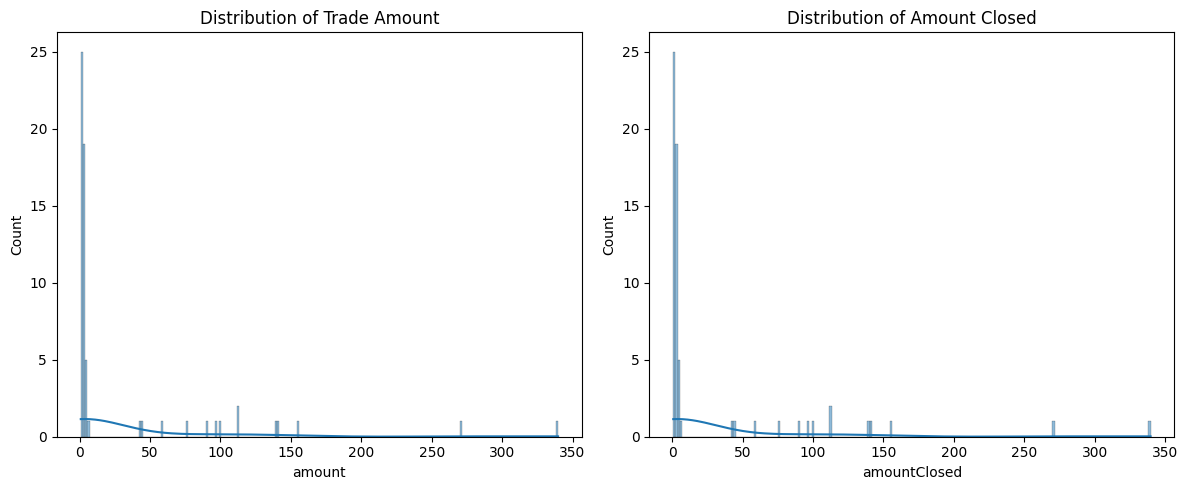

In [45]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['amount'], kde=True)
plt.title('Distribution of Trade Amount')

plt.subplot(1, 2, 2)
sns.histplot(df['amountClosed'], kde=True)
plt.title('Distribution of Amount Closed')

plt.tight_layout()
plt.show()

### Distribution of Risk/Reward Ratios

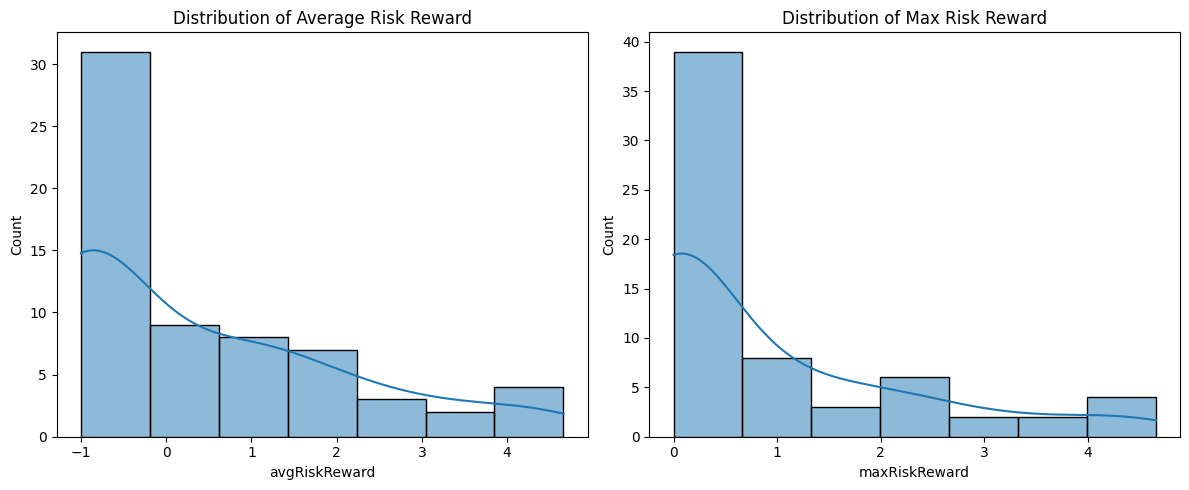

In [46]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['avgRiskReward'], kde=True)
plt.title('Distribution of Average Risk Reward')

plt.subplot(1, 2, 2)
sns.histplot(df['maxRiskReward'], kde=True)
plt.title('Distribution of Max Risk Reward')

plt.tight_layout()
plt.show()

### Realized Balance Over Time

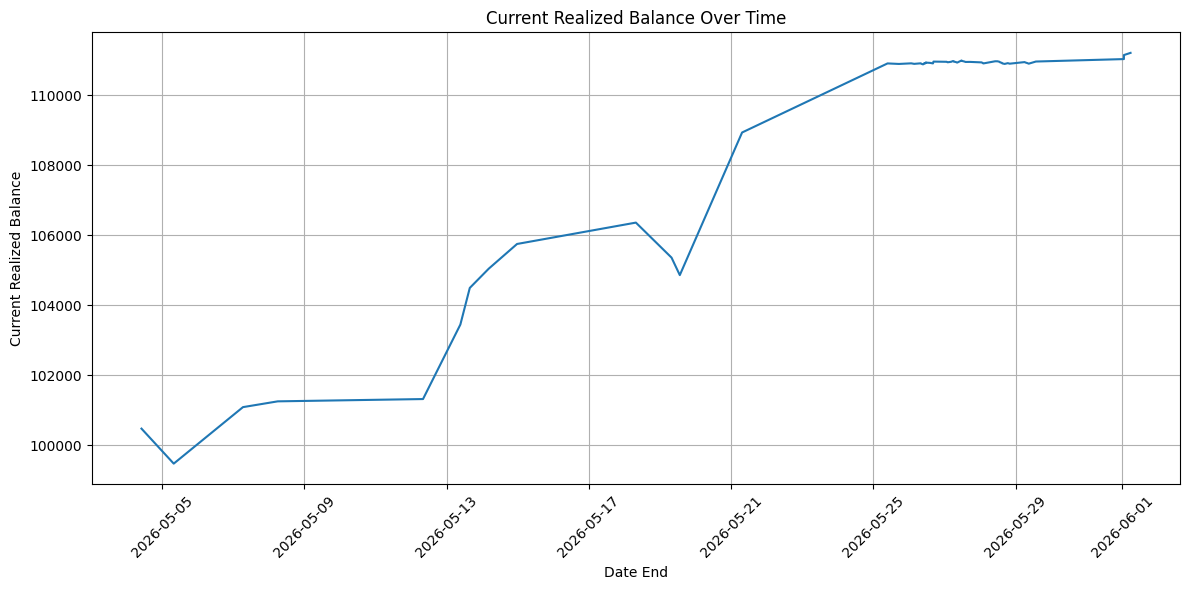

In [47]:
df_sorted_by_end_date = df.sort_values('dateEnd')

plt.figure(figsize=(12, 6))
sns.lineplot(x='dateEnd', y='currentRealizedBalance', data=df_sorted_by_end_date)
plt.title('Current Realized Balance Over Time')
plt.xlabel('Date End')
plt.ylabel('Current Realized Balance')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
filtered_trades = df[(df['rPnL'] > -30) & (df['rPnL'] < 30)]

if not filtered_trades.empty:
    average_duration_filtered = filtered_trades['tradeDuration'].mean()
    print(f"Average duration of trades with |rPnL| < $30: {average_duration_filtered:.2f} minutes")
else:
    print("No trades found with |rPnL| < $30.")

Average duration of trades with |rPnL| < $30: 35.52 minutes


### Visualizing Trades with |rPnL| < $30

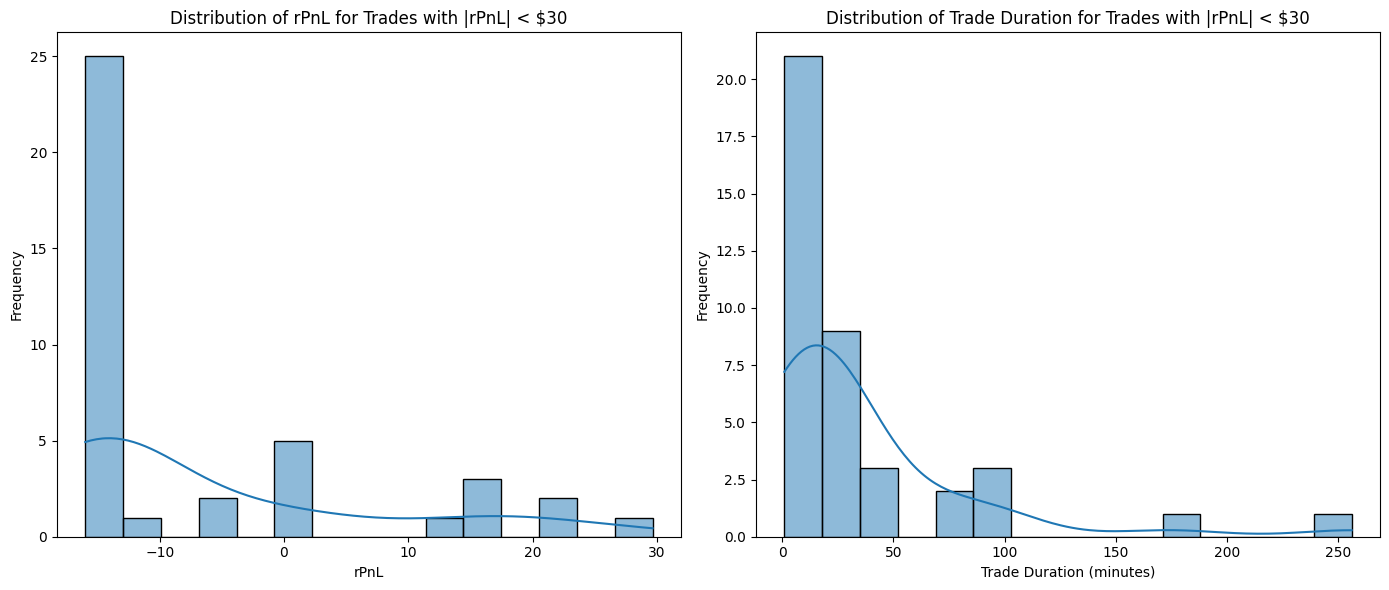

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

if not filtered_trades.empty:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(filtered_trades['rPnL'], kde=True, bins=15)
    plt.title('Distribution of rPnL for Trades with |rPnL| < $30')
    plt.xlabel('rPnL')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.histplot(filtered_trades['tradeDuration'], kde=True, bins=15)
    plt.title('Distribution of Trade Duration for Trades with |rPnL| < $30')
    plt.xlabel('Trade Duration (minutes)')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()
else:
    print("No trades to visualize for |rPnL| < $30.")

### Daily Performance Metrics
To analyze daily drawdown, net profit, and number of profitable/negative trades, we need to group the data by day.

In [50]:
df_daily = df.copy()
df_daily['tradeDate'] = df_daily['dateEnd'].dt.date

daily_summary = df_daily.groupby('tradeDate').agg(
    daily_net_profit=('rPnL', 'sum'),
    profitable_trades=('rPnL', lambda x: (x > 0).sum()),
    negative_trades=('rPnL', lambda x: (x < 0).sum())
).reset_index()

# Calculate cumulative realized balance for drawdown
df_sorted_by_date = df_daily.sort_values(by='dateEnd')
df_sorted_by_date['cumulative_balance'] = df_sorted_by_date['currentRealizedBalance']

daily_max_balance = df_sorted_by_date.groupby('tradeDate')['cumulative_balance'].cummax()
df_sorted_by_date['peak'] = daily_max_balance
df_sorted_by_date['drawdown'] = df_sorted_by_date['peak'] - df_sorted_by_date['cumulative_balance']

# Get the daily max drawdown
daily_max_drawdown = df_sorted_by_date.groupby('tradeDate')['drawdown'].max().reset_index()

display(daily_summary.head())
display(daily_max_drawdown.head())

,tradeDate,daily_net_profit,profitable_trades,negative_trades
0,2026-05-04,477.54,1,0
1,2026-05-05,-1000.03,0,1
2,2026-05-07,1613.92,1,0
3,2026-05-08,165.05,1,0
4,2026-05-12,65.47,1,0


,tradeDate,drawdown
0,2026-05-04,0.0
1,2026-05-05,0.0
2,2026-05-07,0.0
3,2026-05-08,0.0
4,2026-05-12,0.0


### Daily Net Profit

/tmp/ipykernel_3367/990181433.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tradeDate', y='daily_net_profit', data=daily_summary, palette='viridis')


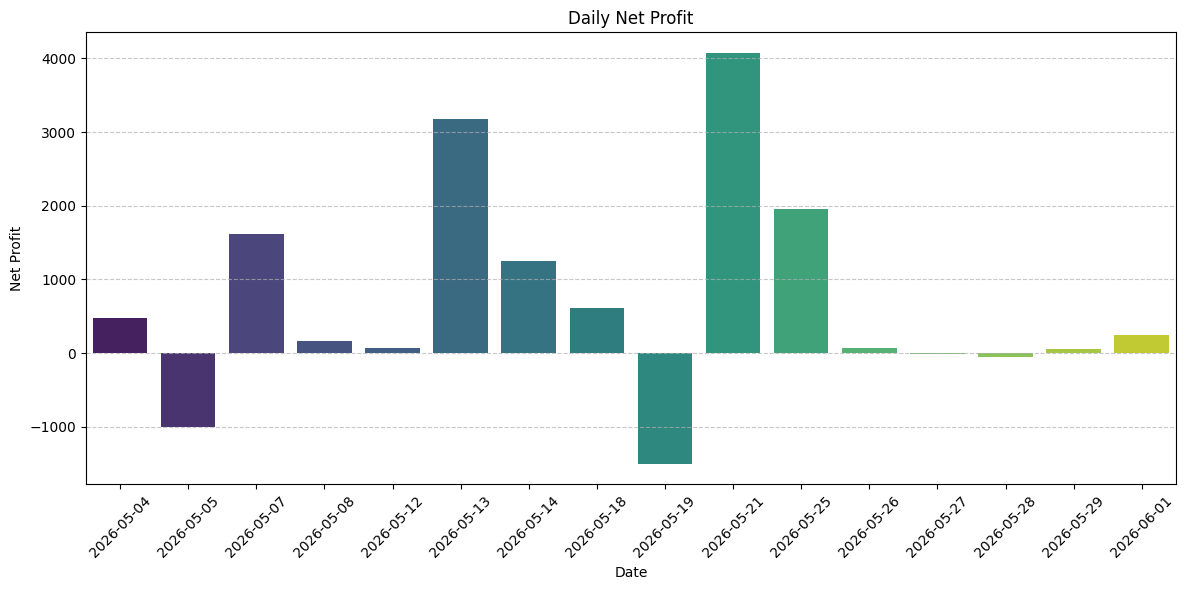

In [51]:
plt.figure(figsize=(12, 6))
sns.barplot(x='tradeDate', y='daily_net_profit', data=daily_summary, palette='viridis')
plt.title('Daily Net Profit')
plt.xlabel('Date')
plt.ylabel('Net Profit')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Number of Profitable vs. Negative Trades Per Day

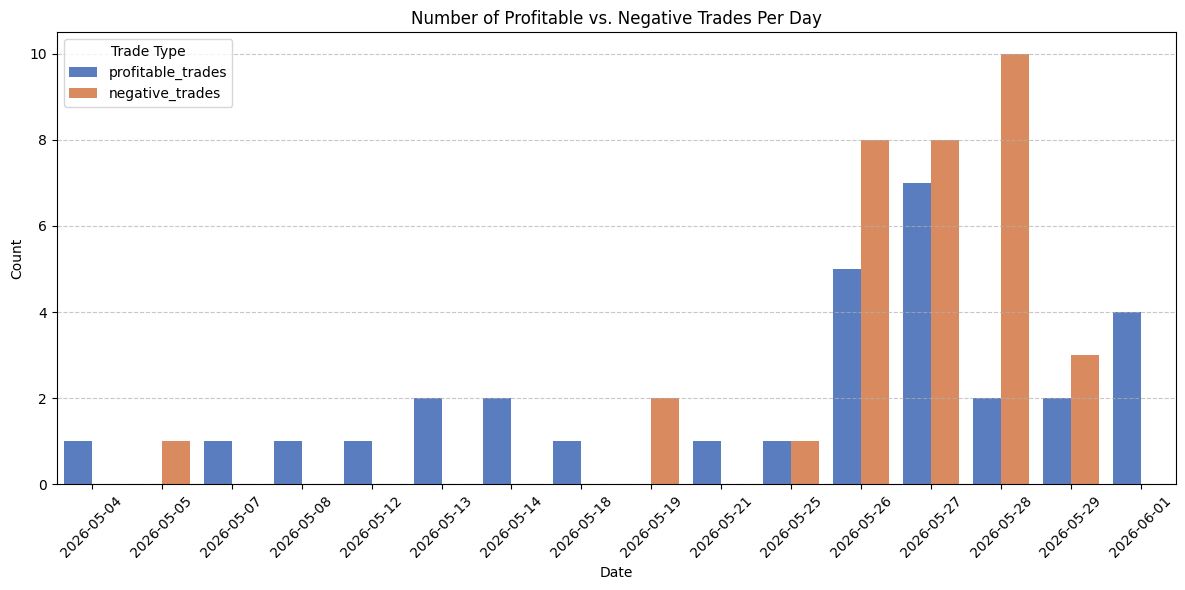

In [52]:
daily_trades_melted = daily_summary.melt(id_vars='tradeDate', value_vars=['profitable_trades', 'negative_trades'], var_name='Trade Type', value_name='Number of Trades')

plt.figure(figsize=(12, 6))
sns.barplot(x='tradeDate', y='Number of Trades', hue='Trade Type', data=daily_trades_melted, palette='muted')
plt.title('Number of Profitable vs. Negative Trades Per Day')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Daily Drawdown

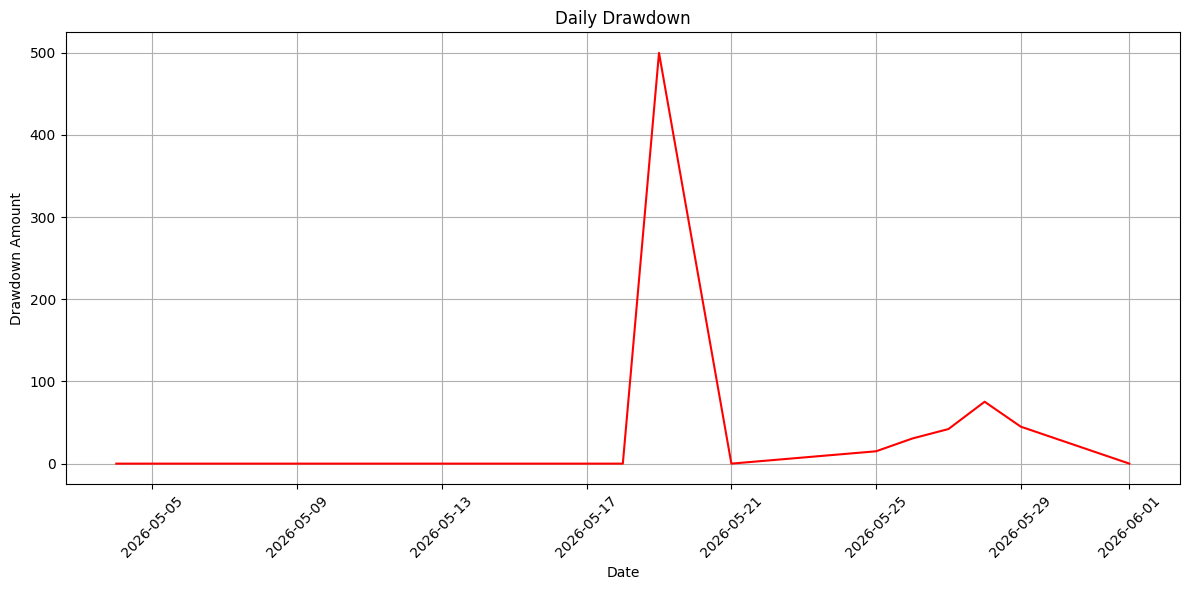

In [53]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='tradeDate', y='drawdown', data=df_sorted_by_date, estimator=max, errorbar=None, color='red')
plt.title('Daily Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown Amount')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Heatmap of Numerical Features

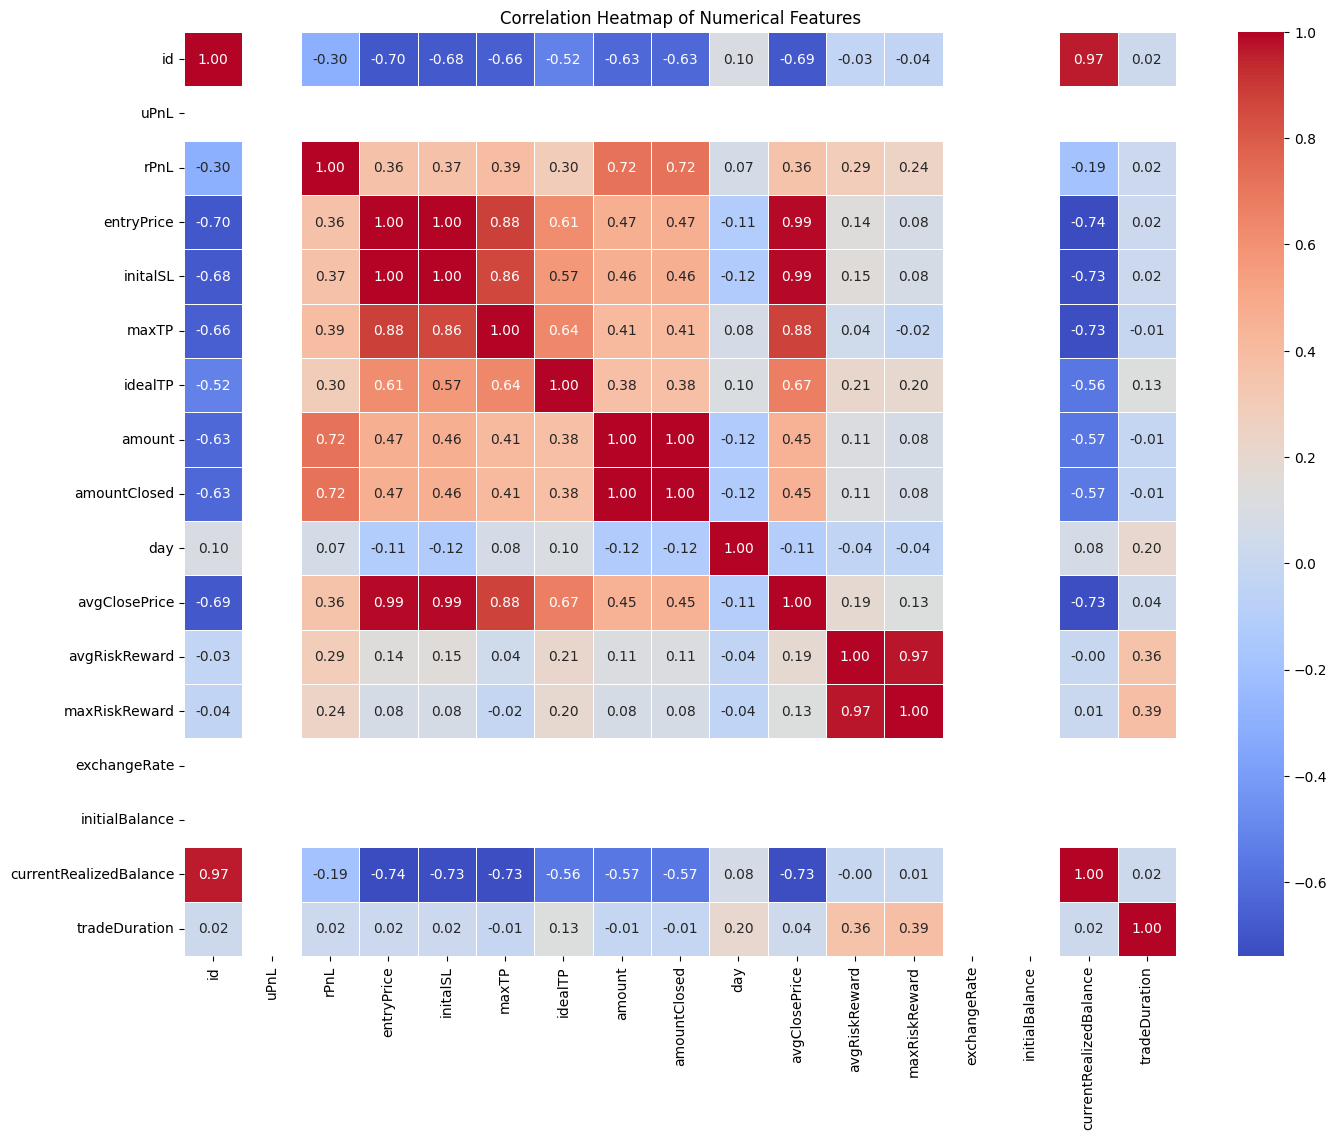

In [54]:
numerical_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(16, 12))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Scatter Plot: rPnL vs. Trade Duration

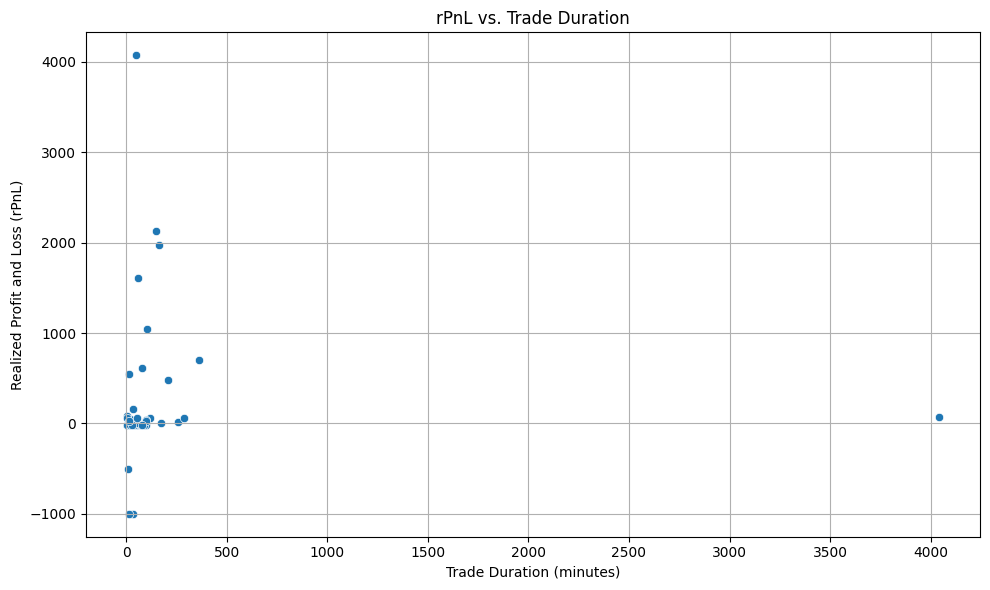

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tradeDuration', y='rPnL', data=df)
plt.title('rPnL vs. Trade Duration')
plt.xlabel('Trade Duration (minutes)')
plt.ylabel('Realized Profit and Loss (rPnL)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Scatter Plot: rPnL vs. Trade Duration for Trades with |rPnL| < $30

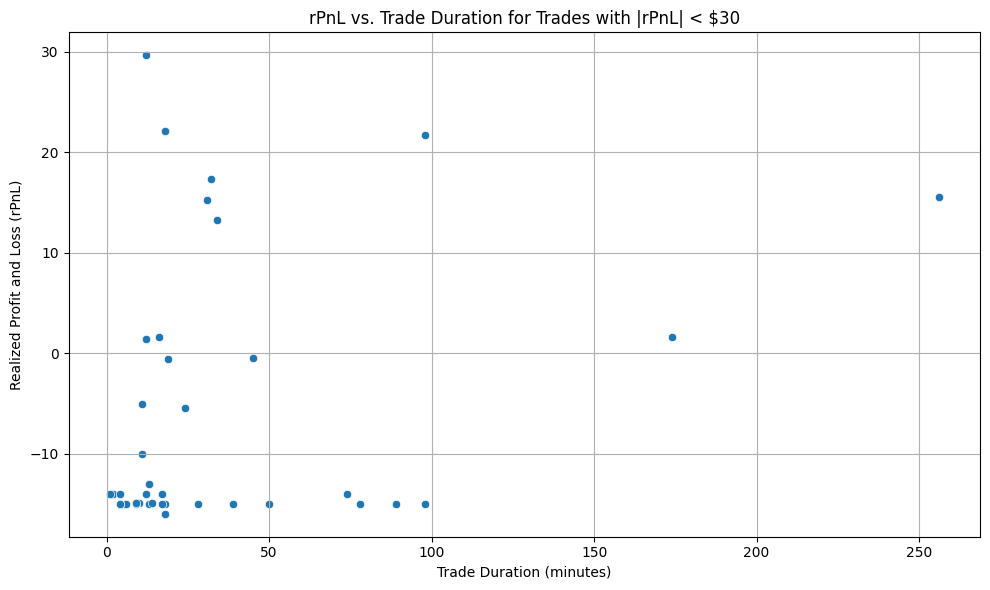

In [56]:
if not filtered_trades.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='tradeDuration', y='rPnL', data=filtered_trades)
    plt.title('rPnL vs. Trade Duration for Trades with |rPnL| < $30')
    plt.xlabel('Trade Duration (minutes)')
    plt.ylabel('Realized Profit and Loss (rPnL)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No filtered trades available to generate the scatter plot.")

### Profit Analysis by Hour for Trades with |rPnL| < $30

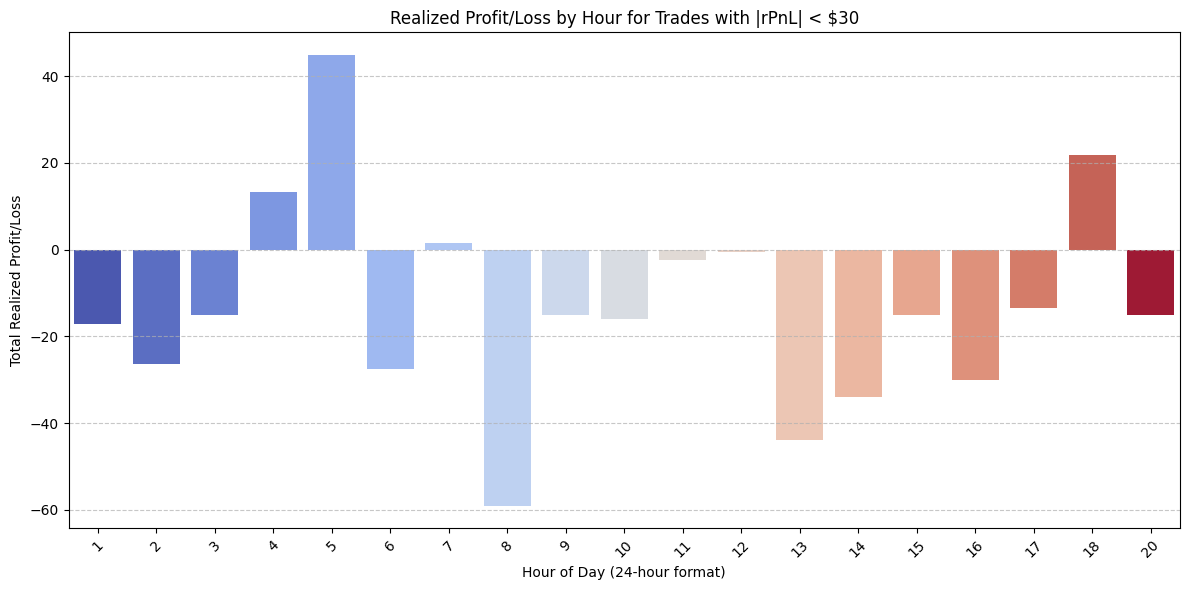

In [57]:
if not filtered_trades.empty:
    # Explicitly create a copy to avoid SettingWithCopyWarning
    filtered_trades_copy = filtered_trades.copy()
    filtered_trades_copy['hourEnd'] = filtered_trades_copy['dateEnd'].dt.hour

    hourly_profit_filtered = filtered_trades_copy.groupby('hourEnd')['rPnL'].sum().reset_index()

    plt.figure(figsize=(12, 6))
    # Adjusting for FutureWarning: Pass hue='hourEnd' and legend=False
    sns.barplot(x='hourEnd', y='rPnL', data=hourly_profit_filtered, palette='coolwarm', hue='hourEnd', legend=False)
    plt.title('Realized Profit/Loss by Hour for Trades with |rPnL| < $30')
    plt.xlabel('Hour of Day (24-hour format)')
    plt.ylabel('Total Realized Profit/Loss')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No filtered trades to analyze for hourly profit.")

### Win Rate for Trades in Profitable Hours (|rPnL| < $30)

In [58]:
if not filtered_trades.empty:
    # Define profitable hours (5 AM and 6 PM based on previous analysis)
    profitable_hours = [5, 18]

    # Filter trades that occurred during profitable hours
    filtered_trades_copy = filtered_trades.copy()
    filtered_trades_copy['hourEnd'] = filtered_trades_copy['dateEnd'].dt.hour
    trades_in_profitable_hours = filtered_trades_copy[filtered_trades_copy['hourEnd'].isin(profitable_hours)]

    if not trades_in_profitable_hours.empty:
        total_trades_profitable_hours = len(trades_in_profitable_hours)
        profitable_trades_profitable_hours = (trades_in_profitable_hours['rPnL'] > 0).sum()

        win_rate_profitable_hours = (profitable_trades_profitable_hours / total_trades_profitable_hours) * 100
        print(f"Win rate for trades in profitable hours (5 AM and 6 PM): {win_rate_profitable_hours:.2f}%")
    else:
        print("No trades found in the profitable hours with |rPnL| < $30.")
else:
    print("No filtered trades available to analyze.")

Win rate for trades in profitable hours (5 AM and 6 PM): 100.00%


### Box Plot: rPnL by Hour of Day

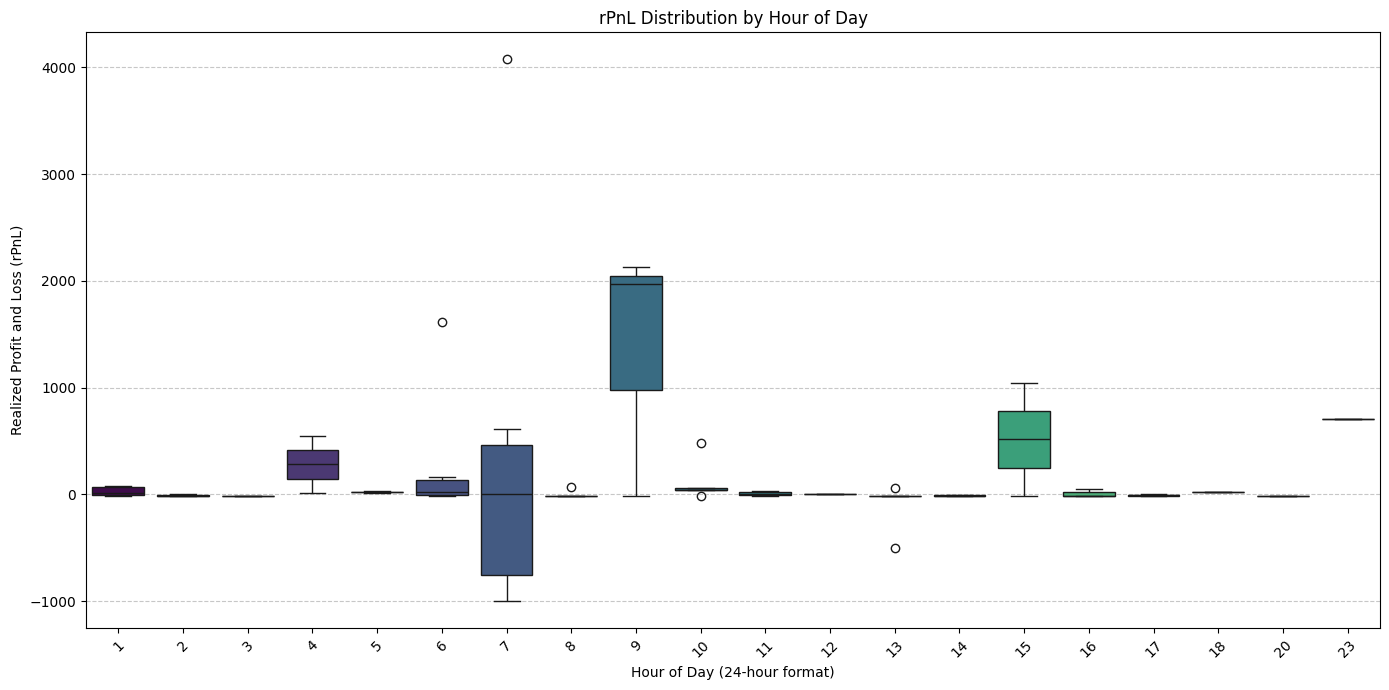

In [59]:
df['hourEnd'] = df['dateEnd'].dt.hour

plt.figure(figsize=(14, 7))
sns.boxplot(x='hourEnd', y='rPnL', data=df, palette='viridis', hue='hourEnd', legend=False)
plt.title('rPnL Distribution by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Realized Profit and Loss (rPnL)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Daily Calendar for High-Risk Trades (|rPnL| > $100)

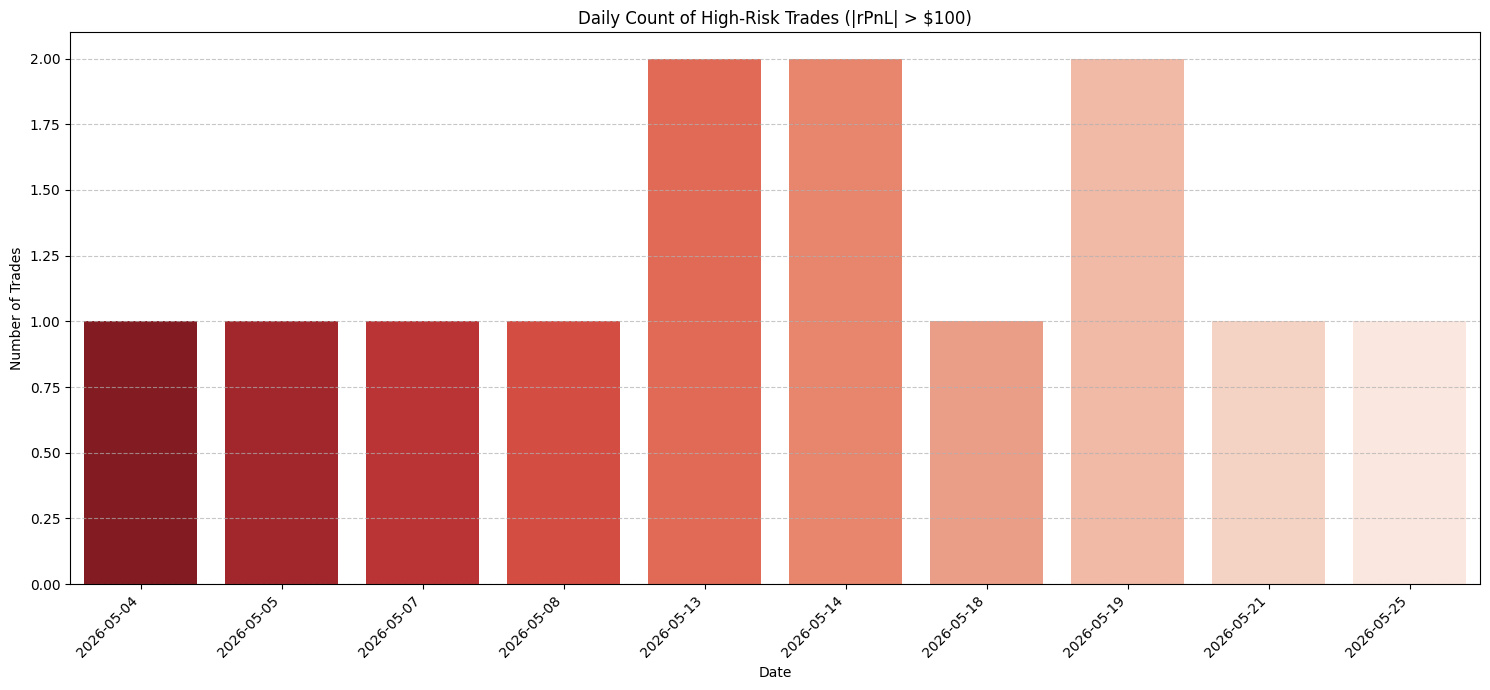

In [60]:
high_risk_trades = df[abs(df['rPnL']) > 100].copy()

if not high_risk_trades.empty:
    high_risk_trades['tradeDate'] = high_risk_trades['dateEnd'].dt.date
    daily_high_risk_counts = high_risk_trades.groupby('tradeDate').size().reset_index(name='trade_count')
    daily_high_risk_counts['tradeDate'] = pd.to_datetime(daily_high_risk_counts['tradeDate']) # Convert back to datetime for plotting

    plt.figure(figsize=(15, 7))
    sns.barplot(x='tradeDate', y='trade_count', data=daily_high_risk_counts, palette='Reds_r', hue='tradeDate', legend=False)
    plt.title('Daily Count of High-Risk Trades (|rPnL| > $100)')
    plt.xlabel('Date')
    plt.ylabel('Number of Trades')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No high-risk trades found to generate a calendar.")

### Daily Calendar for Low-Risk Trades (|rPnL| < $30)

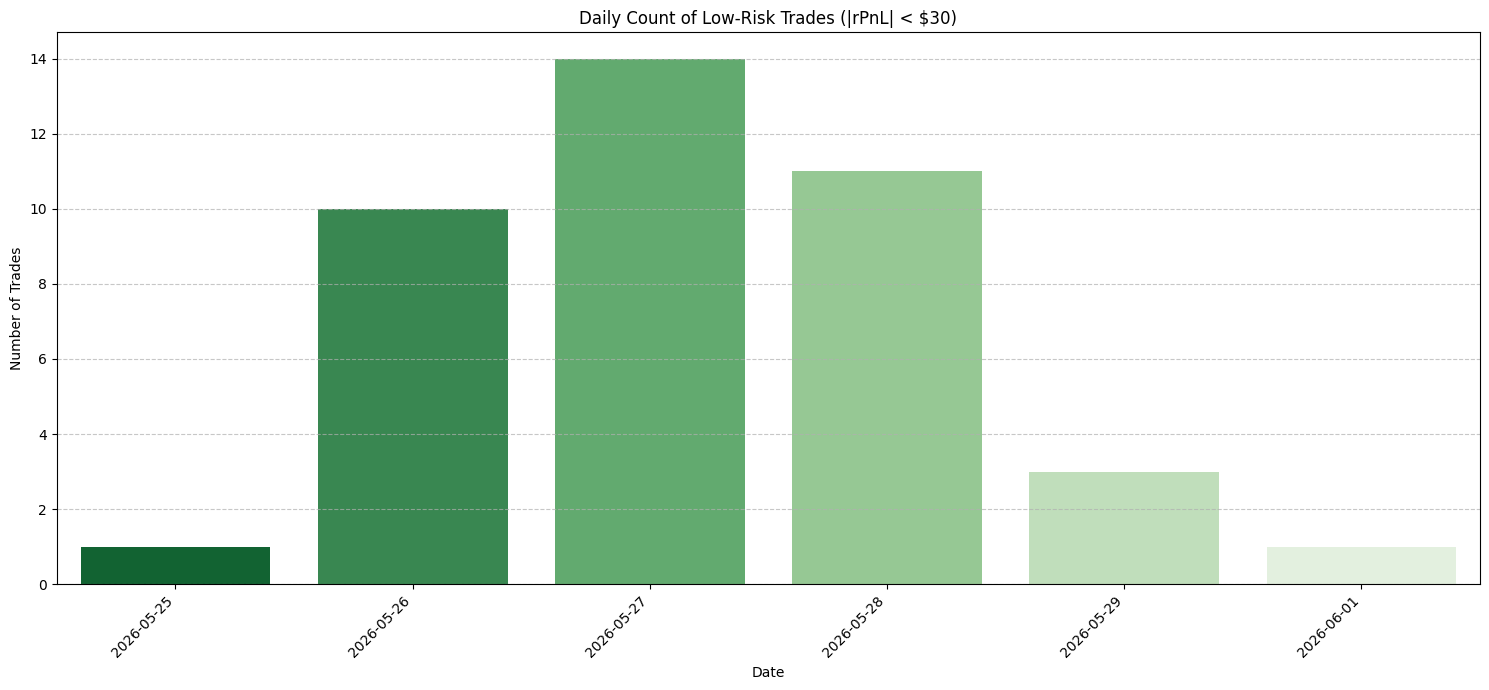

In [61]:
low_risk_trades = df[abs(df['rPnL']) < 30].copy()

if not low_risk_trades.empty:
    low_risk_trades['tradeDate'] = low_risk_trades['dateEnd'].dt.date
    daily_low_risk_counts = low_risk_trades.groupby('tradeDate').size().reset_index(name='trade_count')
    daily_low_risk_counts['tradeDate'] = pd.to_datetime(daily_low_risk_counts['tradeDate']) # Convert back to datetime for plotting

    plt.figure(figsize=(15, 7))
    sns.barplot(x='tradeDate', y='trade_count', data=daily_low_risk_counts, palette='Greens_r', hue='tradeDate', legend=False)
    plt.title('Daily Count of Low-Risk Trades (|rPnL| < $30)')
    plt.xlabel('Date')
    plt.ylabel('Number of Trades')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No low-risk trades found to generate a calendar.")

### Daily Profit/Loss for High-Risk Trades (|rPnL| > $100)

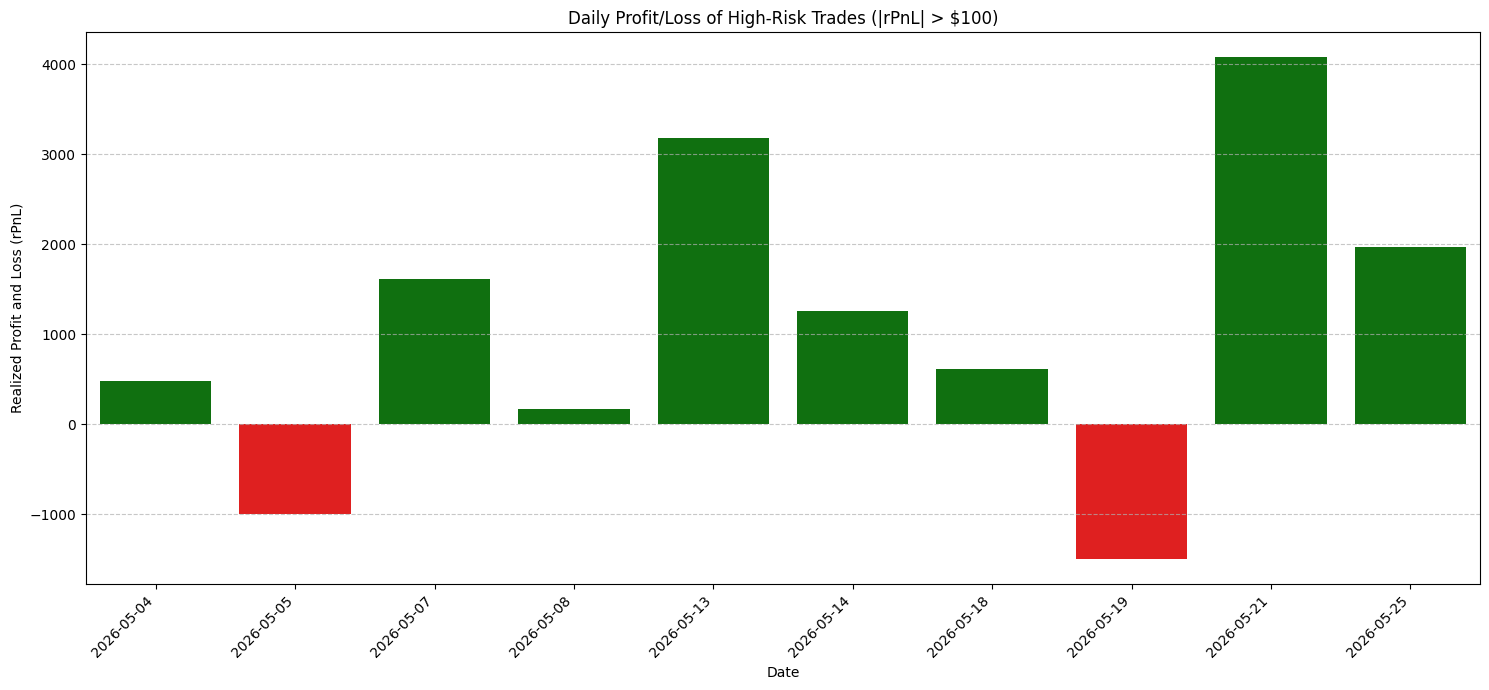

In [62]:
if not high_risk_trades.empty:
    daily_high_risk_profit = high_risk_trades.groupby('tradeDate')['rPnL'].sum().reset_index()
    daily_high_risk_profit['tradeDate'] = pd.to_datetime(daily_high_risk_profit['tradeDate'])

    # Create a color list based on profit/loss
    colors_high_risk = ['green' if x > 0 else 'red' for x in daily_high_risk_profit['rPnL']]

    plt.figure(figsize=(15, 7))
    sns.barplot(x='tradeDate', y='rPnL', data=daily_high_risk_profit, palette=colors_high_risk, hue='tradeDate', legend=False)
    plt.title('Daily Profit/Loss of High-Risk Trades (|rPnL| > $100)')
    plt.xlabel('Date')
    plt.ylabel('Realized Profit and Loss (rPnL)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No high-risk trades found to generate a daily profit/loss calendar.")

### Daily Profit/Loss for Low-Risk Trades (|rPnL| < $30)

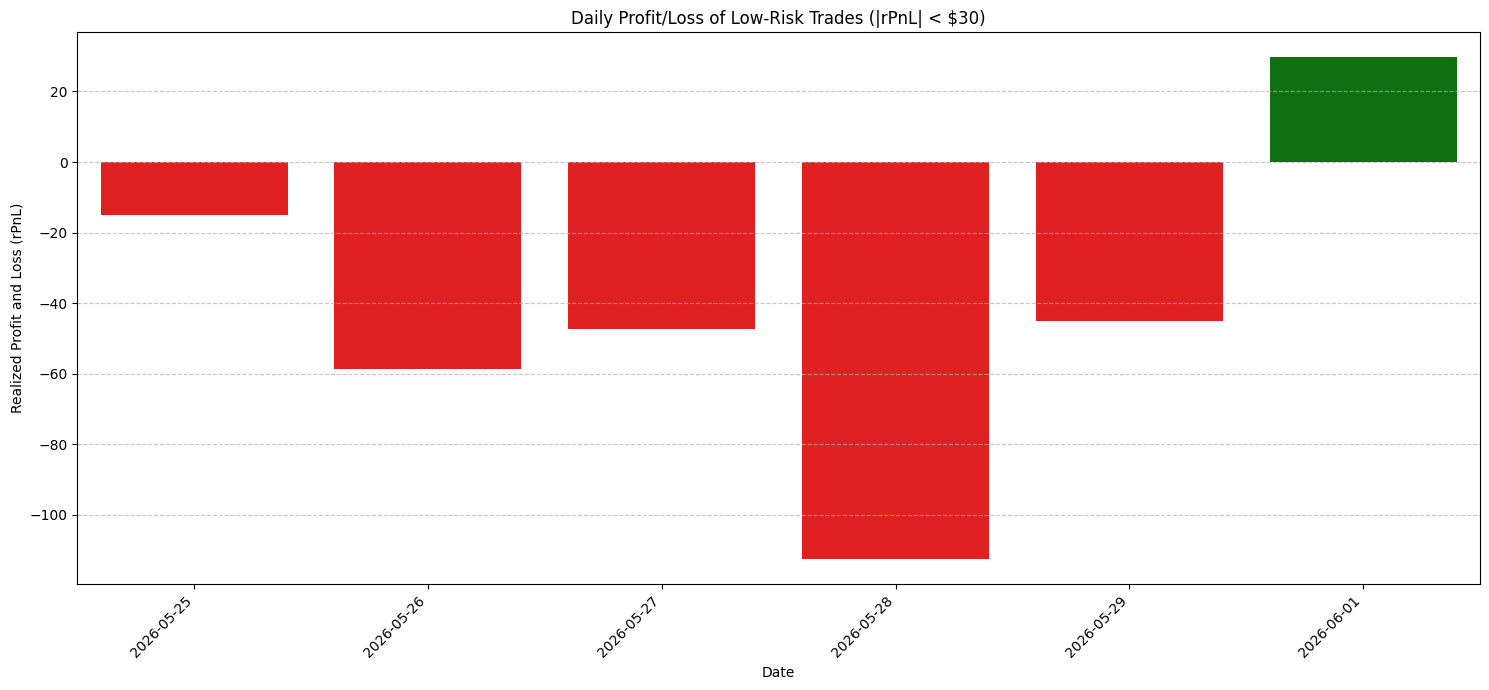

In [63]:
if not low_risk_trades.empty:
    daily_low_risk_profit = low_risk_trades.groupby('tradeDate')['rPnL'].sum().reset_index()
    daily_low_risk_profit['tradeDate'] = pd.to_datetime(daily_low_risk_profit['tradeDate'])

    # Create a color list based on profit/loss
    colors_low_risk = ['green' if x > 0 else 'red' for x in daily_low_risk_profit['rPnL']]

    plt.figure(figsize=(15, 7))
    sns.barplot(x='tradeDate', y='rPnL', data=daily_low_risk_profit, palette=colors_low_risk, hue='tradeDate', legend=False)
    plt.title('Daily Profit/Loss of Low-Risk Trades (|rPnL| < $30)')
    plt.xlabel('Date')
    plt.ylabel('Realized Profit and Loss (rPnL)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No low-risk trades found to generate a daily profit/loss calendar.")

In [64]:
print('DataFrame Info:')
df.info()

print('\nDataFrame Description:')
display(df.describe(include='all'))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      64 non-null     int64         
 1   dateStart               64 non-null     datetime64[ns]
 2   dateEnd                 64 non-null     datetime64[ns]
 3   pair                    64 non-null     object        
 4   uPnL                    64 non-null     int64         
 5   rPnL                    64 non-null     float64       
 6   side                    64 non-null     object        
 7   entryPrice              64 non-null     float64       
 8   initalSL                64 non-null     float64       
 9   maxTP                   64 non-null     float64       
 10  idealTP                 64 non-null     float64       
 11  amount                  64 non-null     float64       
 12  amountClosed            64 non-null 

,id,dateStart,dateEnd,pair,uPnL,rPnL,side,entryPrice,initalSL,maxTP,...,status,day,avgClosePrice,avgRiskReward,maxRiskReward,exchangeRate,initialBalance,currentRealizedBalance,tradeDuration,hourEnd
count,6.400000e+01,64,64,64,64.0,64.000000,64,64.000000,64.000000,64.000000,...,64,64.000000,64.000000,64.000000,64.000000,64.0,64.0,64.000000,64.000000,64.000000
unique,NaN,NaN,NaN,1,NaN,NaN,2,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,XAUUSD,NaN,NaN,buy,NaN,NaN,NaN,...,closed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,64,NaN,NaN,40,NaN,NaN,NaN,...,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.345671e+08,2026-05-24 19:53:11.249999872,2026-05-24 21:48:30,NaN,0.0,175.158594,NaN,4519.691141,4518.250078,4534.610625,...,NaN,2.984375,4519.413737,0.395000,0.903594,1.0,100000.0,109474.187500,115.312500,9.000000
min,2.340207e+08,2026-05-04 06:35:00,2026-05-04 10:01:00,NaN,0.0,-1000.030000,NaN,4377.500000,4371.321000,4403.022000,...,NaN,1.000000,4383.948020,-1.000000,0.000000,1.0,100000.0,99477.510000,1.000000,1.000000
25%,2.346321e+08,2026-05-26 01:47:30,2026-05-26 03:02:15,NaN,0.0,-14.972500,NaN,4489.833250,4486.098250,4517.539000,...,NaN,2.000000,4484.403162,-1.000000,0.000000,1.0,100000.0,110895.820000,11.750000,6.000000
50%,2.346404e+08,2026-05-27 04:30:00,2026-05-27 05:02:30,NaN,0.0,-0.505000,NaN,4511.725500,4508.419000,4517.539000,...,NaN,3.000000,4511.652445,-0.045000,0.000000,1.0,100000.0,110924.430000,21.500000,8.500000
75%,2.346482e+08,2026-05-28 11:31:30,2026-05-28 12:07:45,NaN,0.0,54.045000,NaN,4534.637750,4539.645500,4517.539000,...,NaN,4.000000,4537.931312,1.225000,1.482500,1.0,100000.0,110955.872500,75.000000,13.000000
max,2.346563e+08,2026-06-01 05:22:00,2026-06-01 05:34:00,NaN,0.0,4074.040000,NaN,4719.105000,4717.081000,4721.678000,...,NaN,5.000000,4720.763960,4.660000,4.660000,1.0,100000.0,111210.150000,4044.000000,23.000000
